In [18]:
import pandas as pd
import os
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
os.getcwd()

'/Users/jessie/Desktop/berk/summer 26/207/watts-the-cost-DATASCI-207'

In [3]:
df = pd.read_parquet('data/cleaned_data.parquet')

In [4]:
X = df.drop(columns=['rate'])
y = df['rate']

In [5]:
# dropping zip code
X = X.drop(columns=["zip"])

# log transforming as specified in project milestone
est_cols = [
    "est",
    "n<5",
    "n5_9",
    "n10_19",
    "n20_49",
    "n50_99",
    "n100_249",
    "n250_499",
    "n500_999",
    "n1000"
]

X[est_cols] = np.log1p(X[est_cols])

# converting rate type index into categorical
X["rate_type_index"] = X["rate_type_index"].astype(str)

In [6]:
# utility columns are numbers stored as strings. convert

utility_cols = [
    "Utility Res Sales MWh",
    "Utility Com Sales MWh",
    "Utility Ind Sales MWh"
]

X[utility_cols] = X[utility_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

#impute nas w median (can change to 0 too)
X[utility_cols] = X[utility_cols].fillna(
    X[utility_cols].median()
)

## one hot encoding, scaling numerical vars

In [9]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [col for col in X.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat",
         OneHotEncoder(drop="first",
                       handle_unknown="ignore",
                      sparse_output=False),
         cat_cols),
        ("num",
         StandardScaler(),
         num_cols)
    ]
)

## splitting data

In [10]:
# 1. Partitioning into training, testing, and validation sets. Splitting into temp and test, then train and validation
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1234)

## Preprocessing

In [11]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

## LR model

In [12]:
def build_model(num_features, learning_rate):

  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,                     # output dim
      input_shape=(num_features,),  # input dim
      use_bias=True,               # use a bias (intercept) param
      kernel_initializer=tf.ones_initializer,  # initialize params to 1
      bias_initializer=tf.ones_initializer,    # initialize bias to 1
  ))

  optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

  model.compile(
      optimizer=optimizer,
      loss='mse',
      metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
            tf.keras.metrics.MeanAbsoluteError(name="mae")
        ]
  )
    
  return model

In [13]:
models = []

lr = [0.0001, 0.001]
epochs = [5, 10, 20]

for i in epochs:
    for j in lr:
        model_tf=build_model(X_train_processed.shape[1], j)
        print(f"epochs={i}, lr={j}")
        history = model_tf.fit(
            X_train_processed,
            y_train,
            epochs=i,
            validation_data=(X_val_processed, y_val),
            verbose=1
        )
        models.append({
            "model": model_tf,
            "history": history,
            "epochs": i,
            "learning_rate": j,
            "val_loss": history.history["val_loss"][-1],
            "val_rmse": history.history["val_rmse"][-1],
            "val_mae": history.history["val_mae"][-1]
        })  

2026-08-03 21:48:44.471682: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-08-03 21:48:44.472111: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-08-03 21:48:44.472490: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-08-03 21:48:44.472809: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-03 21:48:44.473436: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


epochs=5, lr=0.0001
Epoch 1/5
  14/3131 [..............................] - ETA: 12s - loss: 573.1345 - rmse: 23.9402 - mae: 17.7450  

2026-08-03 21:48:45.127738: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-08-03 21:48:45.144083: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


3131/3131 [==============================] - 13s 4ms/step - loss: 51.1228 - rmse: 7.1500 - mae: 4.0028 - val_loss: 6.0569 - val_rmse: 2.4611 - val_mae: 1.7748
Epoch 2/5
3131/3131 [==============================] - 12s 4ms/step - loss: 3.5005 - rmse: 1.8710 - mae: 1.3191 - val_loss: 1.8577 - val_rmse: 1.3630 - val_mae: 1.0011
Epoch 3/5
3131/3131 [==============================] - 13s 4ms/step - loss: 1.3655 - rmse: 1.1686 - mae: 0.8484 - val_loss: 0.9583 - val_rmse: 0.9789 - val_mae: 0.7279
Epoch 4/5
3131/3131 [==============================] - 13s 4ms/step - loss: 0.7886 - rmse: 0.8880 - mae: 0.6572 - val_loss: 0.6407 - val_rmse: 0.8005 - val_mae: 0.5971
Epoch 5/5
3131/3131 [==============================] - 13s 4ms/step - loss: 0.5579 - rmse: 0.7469 - mae: 0.5553 - val_loss: 0.4871 - val_rmse: 0.6979 - val_mae: 0.5185


epochs=5, lr=0.001
Epoch 1/5
  28/3131 [..............................] - ETA: 11s - loss: 280.7093 - rmse: 16.7544 - mae: 11.5703 

...

2026-08-03 21:55:15.513465: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


3131/3131 [==============================] - 14s 4ms/step - loss: 51.1228 - rmse: 7.1500 - mae: 4.0028 - val_loss: 6.0569 - val_rmse: 2.4611 - val_mae: 1.7748
Epoch 2/20
3131/3131 [==============================] - 13s 4ms/step - loss: 3.5005 - rmse: 1.8710 - mae: 1.3191 - val_loss: 1.8577 - val_rmse: 1.3630 - val_mae: 1.0011
Epoch 3/20
3131/3131 [==============================] - 12s 4ms/step - loss: 1.3655 - rmse: 1.1686 - mae: 0.8484 - val_loss: 0.9583 - val_rmse: 0.9789 - val_mae: 0.7279
Epoch 4/20
3131/3131 [==============================] - 12s 4ms/step - loss: 0.7886 - rmse: 0.8880 - mae: 0.6572 - val_loss: 0.6407 - val_rmse: 0.8005 - val_mae: 0.5971
Epoch 5/20
3131/3131 [==============================] - 12s 4ms/step - loss: 0.5579 - rmse: 0.7469 - mae: 0.5553 - val_loss: 0.4871 - val_rmse: 0.6979 - val_mae: 0.5185
Epoch 6/20
3131/3131 [==============================] - 12s 4ms/step - loss: 0.4374 - rmse: 0.6614 - mae: 0.4899 - val_loss: 0.3955 - val_rmse: 0.6289 - val_mae: 0.4

epochs=20, lr=0.001
Epoch 1/20
  30/3131 [..............................] - ETA: 11s - loss: 278.1730 - rmse: 16.6785 - mae: 11.4688 

2026-08-03 21:59:29.496890: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


3131/3131 [==============================] - 14s 4ms/step - loss: 6.0770 - rmse: 2.4652 - mae: 0.9441 - val_loss: 0.2273 - val_rmse: 0.4768 - val_mae: 0.3398
Epoch 2/20
3131/3131 [==============================] - 12s 4ms/step - loss: 0.1528 - rmse: 0.3909 - mae: 0.2638 - val_loss: 0.1082 - val_rmse: 0.3290 - val_mae: 0.2069
Epoch 3/20
3131/3131 [==============================] - 13s 4ms/step - loss: 0.0862 - rmse: 0.2936 - mae: 0.1762 - val_loss: 0.0725 - val_rmse: 0.2693 - val_mae: 0.1497
Epoch 4/20
3131/3131 [==============================] - 12s 4ms/step - loss: 0.0617 - rmse: 0.2484 - mae: 0.1331 - val_loss: 0.0564 - val_rmse: 0.2374 - val_mae: 0.1172
Epoch 5/20
3131/3131 [==============================] - 14s 4ms/step - loss: 0.0495 - rmse: 0.2226 - mae: 0.1075 - val_loss: 0.0476 - val_rmse: 0.2182 - val_mae: 0.0989
Epoch 6/20
3131/3131 [==============================] - 14s 5ms/step - loss: 0.0424 - rmse: 0.2059 - mae: 0.0915 - val_loss: 0.0417 - val_rmse: 0.2043 - val_mae: 0.08

In [14]:
best = min(models, key=lambda x: x["val_rmse"])

best_model = best["model"]

print(best["epochs"])
print(best["learning_rate"])
print(best["val_rmse"])

20
0.001
0.1280503273010254


In [16]:
final_model = build_model(X_train_processed.shape[1], 0.001)

history = final_model.fit(
    X_train_processed,
    y_train,
    epochs=20,
    validation_data=(X_val_processed, y_val),
    verbose=0)

2026-08-04 00:05:19.244235: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


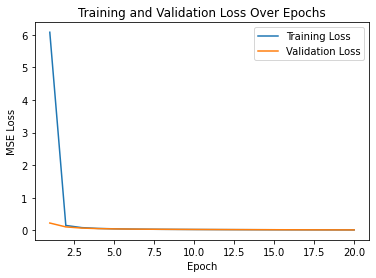

In [21]:
epochs = range(1, len(history.history["loss"]) + 1)


plt.plot(epochs, history.history["loss"], label="Training Loss")
plt.plot(epochs, history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.show()

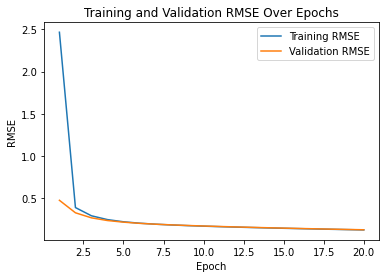

In [22]:
epochs = range(1, len(history.history["rmse"]) + 1)

plt.plot(epochs, history.history["rmse"], label="Training RMSE")
plt.plot(epochs, history.history["val_rmse"], label="Validation RMSE")

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training and Validation RMSE Over Epochs")
plt.legend()
plt.show()

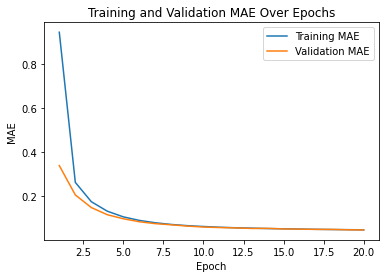

In [23]:
epochs = range(1, len(history.history["mae"]) + 1)

plt.plot(epochs, history.history["mae"], label="Training MAE")
plt.plot(epochs, history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training and Validation MAE Over Epochs")
plt.legend()
plt.show()

## Evaluation, Generalization

In [24]:
train_loss, train_rmse, train_mae = final_model.evaluate(X_train_processed, y_train, verbose=False)
test_loss, test_rmse, test_mae = final_model.evaluate(X_test_processed, y_test, verbose=False)

training RMSE: 0.12464382499456406
training MAE: 0.04808510094881058
test RMSE: 0.12062544375658035
test MAE: 0.047611307352781296


In [26]:
print("training RMSE:", train_rmse)
print("training MAE:", train_mae)

print("\ntest RMSE:", test_rmse)
print("test MAE:", test_mae)

training RMSE: 0.12464382499456406
training MAE: 0.04808510094881058

test RMSE: 0.12062544375658035
test MAE: 0.047611307352781296
